

```
# This is formatted as code
```

# 2024 11 PPP
* [1 - LAE Rating Tool for 2024 11 PPP](https://editor.p5js.org/compair/full/LJWMz_CB3)
* [2 - LAE Rating Tool for 2024 11 PPP](https://editor.p5js.org/compair/full/wLI_CWsDE)


# open, install, import

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%pip install choix
%pip install kendall-w
%pip install pairwise-ranking
%pip install --upgrade pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: networkx
    Found existing installation: networkx 3.4.2
    Uninstalling networkx-3.4.2:
      Successfully uninstalled networkx-3.4.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, bu

In [ ]:
import os
from natsort import natsorted, ns
import numpy as np
import pandas as pd

import choix
import ranking
import kendall_w.kendall_w as kw

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
#np.set_printoptions(precision=3, suppress=True)

! python --version
print("pandas", pd.__version__)

Python 3.11.11
pandas 2.2.3


In [ ]:
maindir = 'drive/MyDrive/Medicine/UKW/Forschig/2024 11 Pauline/'

# Module

In [ ]:
import os
import pandas as pd
import choix
import ranking
import nest_asyncio


class ComPair:
    """A class to represent an experiment in Pairwise Comparison
    what an abomination this first try to encapsulate EVERYTHING in one class."""

    def __init__(self, data_path, win_lose_col_tuple):

        self.data_path = data_path

        self.data = pd.DataFrame()
        self.dfs = []  # list of dataframes
        self.column_winner, self.column_loser = win_lose_col_tuple

        self.matches = None
        self.scores = None
        self.depth_and_luck = None

        self.mapping_number_to_name = None
        self.column_names = [
            "rater",
            "n_stack",
            "winner",
            "loser",
            "msecs",
            "modus",
            "kernelWinner",
            "kernelLoser",
        ]

        self.load_data()
        self.make_match_list()
        self.map_label_number_to_name()

    def __str__(self):
        self.data.name

    def __repr__(self):
        return f"Experiment('{self.name}')"

    def load_data(self):
        """Load experiment data from file or directory containing multiple files."""

        p = self.data_path
        if os.path.isdir(p):
            for file in os.listdir(p):
                if file.endswith((".csv", ".txt")):
                    try:
                        df_temp = pd.read_csv(
                            os.path.join(p, file),
                            header=None,
                            names=self.column_names,
                        )
                        df_temp["msecs_diff"] = df_temp["msecs"].diff()
                        self.dfs.append(df_temp)
                    except Exception as e:
                        print(f"Error reading {file}: {e}")

            if self.dfs:
                try:
                    self.data = pd.concat(self.dfs, ignore_index=True)
                    self.data["matches"] = self.data[
                        [self.column_winner, self.column_loser]
                        ].apply(tuple, axis=1)
                except Exception as e:
                    print(f"Error concatenating dataframes: {e}\n possibly wrong winner/loser")

        elif os.path.isfile(p) and p.endswith((".csv", ".txt")):
            try:
                self.data = pd.read_csv(
                    p, header=None, names=self.column_names
                )
            except Exception as e:
                raise ValueError(f"Error loading CSV/TXT file: {e}")

        elif p.endswith(".xlsx"):
            try:
                self.data = pd.read_excel(p)
            except Exception as e:
                raise ValueError(f"Error loading Excel file: {e}")

        return self.data

    def map_label_number_to_name(self):

        df = self.data[["winner", "loser", "kernelWinner", "kernelLoser"]]
        # Combine winner and loser with their corresponding kernels
        # Create dictionaries for both winner/kernelWinner and loser/kernelLoser pairs
        winner_dict = dict(zip(df["winner"], df["kernelWinner"]))
        loser_dict = dict(zip(df["loser"], df["kernelLoser"]))

        # Merge the two dictionaries:
        # The ** operator unpacks each dictionary and combines them.
        # If there are overlapping keys, the values from the second dictionary (loser_dict) will overwrite the first (winner_dict).
        self.mapping_number_to_name = {**winner_dict, **loser_dict}
        return self.mapping_number_to_name


    def make_match_list(self):
        """Load the match list from DataFrame"""
        if self.data.empty:
            raise ValueError("No data available to load.")
        data = self.data[[self.column_winner, self.column_loser]].dropna()
        self.matches = [
            {"winner": d[self.column_winner], "loser": d[self.column_loser]}
            for _, d in data.iterrows()
        ]

        return self.matches

    def compute_scores(self):
        """Calculate scores using the 'ranking' library."""
        nest_asyncio.apply()  # Needed for running inside a Jupyter notebook

        if self.matches is None:
            raise ValueError("No match list data available.")
        # self.depth_and_luck = ranking.scores(self.matches)
        self.scores = ranking.scores(self.matches)

        return self.scores

    def compute_depth_and_luck(self):
        """Calculate luck and depth using the 'ranking' library."""
        nest_asyncio.apply()

        if self.matches is None:
            raise ValueError("No match list data available.")
        self.depth_and_luck = ranking.depth_and_luck(self.matches)

        return self.depth_and_luck

    def compute_choix(self, rater=None, method="islr"):
        """Calculate rankings using the 'choix' library."""
        if self.data.empty:
            raise ValueError("No data loaded.")
        if rater:
            temp_data = self.data[self.data["rater"] == rater]
        else:
            temp_data = self.data
        match_data = temp_data.matches.tolist()
        n_items = len(set(self.data[["winner", "loser"]].values.flatten()))
        if method == "ep":
            # 'probit' for Thurstone, 'logit' for Bradley-Terry
            mean, cov = choix.ep_pairwise(
                n_items, match_data, model="logit", alpha=10e-4
            )
            params = mean
        elif method == "islr":
            params = choix.ilsr_pairwise(n_items, match_data, alpha=10e-4)

        if self.mapping_number_to_name is not None:
            mapped = {self.mapping_number_to_name[i]: p for i, p in enumerate(params)}

        d = {"label": np.arange(len(params)), "score": params}
        df = pd.DataFrame(data=d).sort_values("score", ascending=False)
        return df


    def filter_by_rater(self, rater):
        """Return a subset of the data filtered by rater."""
        return self.data[self.data["rater"] == rater]

    def process_by_rater(self, process):
        """Run computations for each unique rater separately without modifying self.data."""
        results = {}
        for rater in self.data["rater"].unique():
            subset = self.filter_by_rater(rater).copy()
            if subset.empty:
                continue

            matches = [
                {"winner": d[self.column_winner], "loser": d[self.column_loser]}
                for _, d in subset.iterrows()
            ]
            print(len(subset))
            if process == "ranks":
                results[rater] = ranking.scores(matches)
            elif process == "choix":
                tuple_list = [ (i['winner'], i['loser']) for i in matches]
                results[rater] = self.compute_choix()
            elif process == "lucky":
                results[rater] = ranking.depth_and_luck(matches)

        return results


# 1. Auswertung

## 1.1 Import

In [ ]:
stack = 'ratings2'
paaf = os.path.join(maindir, stack)

# import the data into module
exp = ComPair(paaf, win_lose_col_tuple=('winner', 'loser'))

# for later mapping
mapping = exp.mapping_number_to_name

exp.data

,rater,n_stack,winner,loser,msecs,modus,kernelWinner,kernelLoser,msecs_diff,matches
0,rob,11,2,3,13547,True,Bv64,Qr48,NaN,"(2, 3)"
1,rob,11,1,2,16744,True,Bv56,Bv64,3197.0,"(1, 2)"
2,rob,11,1,5,17656,True,Bv56,Qr64,912.0,"(1, 5)"
3,rob,11,0,2,18767,True,Bv48,Bv64,1111.0,"(0, 2)"
4,rob,11,2,5,20240,True,Bv64,Qr64,1473.0,"(2, 5)"
...,...,...,...,...,...,...,...,...,...,...
9115,PaulineP,7,0,5,3910282,True,Bv48,Qr64,861.0,"(0, 5)"
9116,PaulineP,7,2,0,3911373,True,Bv64,Bv48,1091.0,"(2, 0)"
9117,PaulineP,7,1,3,3913335,True,Bv56,Qr48,1962.0,"(1, 3)"
9118,PaulineP,7,1,4,3914148,True,Bv56,Qr56,813.0,"(1, 4)"


In [ ]:
exp.compute_choix().replace(mapping).to_excel(os.path.join(maindir, f"output/{stack}_choix.xlsx"))
exp.compute_choix().replace(mapping)

,label,score
2,Bv64,1.148597
1,Bv56,1.139488
0,Bv48,0.041464
5,Qr64,-0.119625
4,Qr56,-0.578296
3,Qr48,-1.631628


## 1.x Kendall W

In [ ]:
results_choix = exp.process_by_rater("choix");
results_choix

1140
1140
1140
1140
1140
1140
1140
1140


{'Linus Desing':    label     score
 1      1  1.133011
 2      2  0.890586
 0      0  0.117538
 5      5 -0.312094
 4      4 -0.453937
 3      3 -1.375104,
 'Huf':    label     score
 1      1  1.133011
 2      2  0.890586
 0      0  0.117538
 5      5 -0.312094
 4      4 -0.453937
 3      3 -1.375104,
 'Krümelmonster':    label     score
 1      1  1.133011
 2      2  0.890586
 0      0  0.117538
 5      5 -0.312094
 4      4 -0.453937
 3      3 -1.375104,
 'Gruschi':    label     score
 1      1  1.133011
 2      2  0.890586
 0      0  0.117538
 5      5 -0.312094
 4      4 -0.453937
 3      3 -1.375104,
 'Julius':    label     score
 1      1  1.133011
 2      2  0.890586
 0      0  0.117538
 5      5 -0.312094
 4      4 -0.453937
 3      3 -1.375104,
 'Pan':    label     score
 1      1  1.133011
 2      2  0.890586
 0      0  0.117538
 5      5 -0.312094
 4      4 -0.453937
 3      3 -1.375104,
 'CS':    label     score
 1      1  1.133011
 2      2  0.890586
 0      0  0.117538


{'SD':    label     score
 1      1  1.133011
 2      2  0.890586
 0      0  0.117538
 5      5 -0.312094
 4      4 -0.453937
 3      3 -1.375104}

In [ ]:
results = exp.process_by_rater('ranks');

Building...



Building: found in cache, done.Messages from stanc:
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
Sampling:   0%
Sampling:   1% (200/24000)
Sampling:   2% (500/24000)
Sampling:  26% (6300/24000)
Sampling:  50% (12000/24000)
Sampling:  75% (18000/24000)
Sampling: 100% (24000/24000)
Sampling: 100% (24000/24000), done.
Messages received during sampling:
  Gradient evaluation took 1.9e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.19 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 2.2e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.22 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.2e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.12 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.2e-05 seconds
  1000 transitions using 10 leapfrog steps

Building...



Building: found in cache, done.Messages from stanc:
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
Sampling:   0%
Sampling:   0% (100/24000)
Sampling:   1% (300/24000)
Sampling:   4% (900/24000)
Sampling:   6% (1400/24000)
Sampling:  28% (6700/24000)
Sampling:  50% (12000/24000)
Sampling:  75% (18000/24000)
Sampling: 100% (24000/24000)
Sampling: 100% (24000/24000), done.
Messages received during sampling:
  Gradient evaluation took 2.3e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.23 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 2e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.2 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.6e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.16 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.2e-0

Building...


...


Building: found in cache, done.Messages from stanc:
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
Sampling:   0%
Sampling:   1% (200/24000)
Sampling:   2% (600/24000)
Sampling:  27% (6400/24000)
Sampling:  50% (12000/24000)
Sampling:  75% (18000/24000)
Sampling: 100% (24000/24000)
Sampling: 100% (24000/24000), done.
Messages received during sampling:
  Gradient evaluation took 1.5e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.15 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 2e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.2 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.2e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.12 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.9e-05 seconds
  1000 transitions using 10 leapfrog steps pe

Building...



Building: found in cache, done.Messages from stanc:
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
Sampling:   0%
Sampling:   1% (300/24000)
Sampling:   2% (600/24000)
Sampling:  26% (6300/24000)
Sampling:  50% (12000/24000)
Sampling:  75% (18000/24000)
Sampling: 100% (24000/24000)
Sampling: 100% (24000/24000), done.
Messages received during sampling:
  Gradient evaluation took 2.2e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.22 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.7e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.17 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.1e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.11 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.1e-05 seconds
  1000 transitions using 10 leapfrog steps

Building...



Building: found in cache, done.Messages from stanc:
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
Sampling:   0%
Sampling:   0% (100/24000)
Sampling:   1% (300/24000)
Sampling:   3% (700/24000)
Sampling:   5% (1100/24000)
Sampling:  28% (6600/24000)
Sampling:  50% (12000/24000)
Sampling:  75% (18000/24000)
Sampling: 100% (24000/24000)
Sampling: 100% (24000/24000), done.
Messages received during sampling:
  Gradient evaluation took 3.8e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.38 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 2e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.2 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.6e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.16 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.6e-0

In [ ]:
rankings = pd.DataFrame({name: res.label for name, res in results.items()})

In [ ]:
rankings

,Linus Desing,Krümelmonster,Gruschi,Julius,Pan,CS,SD
1,Bv64,Bv56,Bv48,Bv56,nan,Bv64,Bv64
2,Bv56,Bv48,Bv56,Bv48,NaN,Bv56,Qr64
3,Bv48,Bv64,Qr48,Bv64,NaN,Qr64,Bv56
4,Qr64,Qr56,Qr56,Qr56,NaN,Qr56,Qr56
5,Qr56,Qr64,Bv64,Qr64,NaN,Bv48,Qr48
6,Qr48,Qr48,Qr64,Qr48,NaN,Qr48,Bv48


In [ ]:
rankings = pd.DataFrame({name: res.label for name, res in results.items()})
rankings

,rob,Pinguin,CS,Gruschi,Julius,Henner,ersde,PaulineP
1,Bv56,Bv56,Bv64,Bv48,Bv56,Bv64,Bv64,Bv64
2,Bv64,Bv64,Qr64,Bv56,Bv48,Qr64,Bv56,Bv56
3,Bv48,Bv48,Bv56,Qr48,Bv64,Bv56,Qr64,Bv48
4,Qr64,Qr64,Qr56,Qr56,Qr56,Qr56,Qr56,Qr64
5,Qr56,Qr56,Bv48,Bv64,Qr64,Bv48,Bv48,Qr56
6,Qr48,Qr48,Qr48,Qr64,Qr48,Qr48,Qr48,Qr48


In [ ]:
df = pd.DataFrame()

for rater in rankings.columns:
  for i, v in enumerate(rankings[rater].values):
    df.loc[rater, v] = i

df = df.astype(np.int32)

In [ ]:
result_list = df.T.values.tolist()
result_list

[[0, 0, 2, 1, 0, 2, 1, 1],
 [1, 1, 0, 4, 2, 0, 0, 0],
 [2, 2, 4, 0, 1, 4, 4, 2],
 [3, 3, 1, 5, 4, 1, 2, 3],
 [4, 4, 3, 3, 3, 3, 3, 4],
 [5, 5, 5, 2, 5, 5, 5, 5]]

In [ ]:
w = kw.compute_w(result_list)
w

0.5857142857142857

## 1.x Luck & Depth

*** pause ***

In [ ]:
ranks = ranking.ranks(match_list_from_rating1)
print(ranks)

# Infer the depth and luck of the hierarchy
params = ranking.depth_and_luck(match_list_from_rating1)
print(f"Depth: {params['depth']:.3f}, Luck: {params['luck']:.3f}")

['Bv56', 'Bv64', 'Bv48', 'Qr64', 'Qr56', 'Qr48']
Depth: 2.014, Luck: 0.168


In [ ]:
params = ranking.depth_and_luck(match_list_from_rating1, model_name="depth_only", num_samples=2000)
print(f"Depth: {params['depth']:.3f}, Luck: {params['luck']:.3f}")

Building...



Building: 32.9s, done.Sampling:   0%
Sampling:   2% (300/12000)
Sampling:   6% (700/12000)
Sampling:  28% (3400/12000)
Sampling:  50% (6000/12000)
Sampling:  75% (9000/12000)
Sampling: 100% (12000/12000)
Sampling: 100% (12000/12000), done.
Messages received during sampling:
  Gradient evaluation took 3.9e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.39 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 2.6e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.26 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 9e-06 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.09 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.5e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.15 seconds.
  Adjust your expectations accordingly!


Depth: 1.533, Luck: 0.000


## 1.x Explore

In [ ]:
df.groupby('matches').sum()

<ipython-input-17-0344f6b99a5d>:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df.groupby('matches').sum()


,win,lose,msecs,modus
matches,,,,
"(0, 3)",0,30,53440.0,10
"(0, 6)",0,54,45151.0,9
"(0, 9)",0,45,28484.0,5
"(0, 12)",0,96,27444.0,8
"(0, 15)",0,150,81548.0,10
...,...,...,...,...
"(17, 12)",272,192,22442.0,16
"(17, 13)",272,208,21240.0,16
"(17, 14)",119,98,37411.0,7


In [ ]:
df.groupby('matches').count()

,rater,n_stack,win,lose,msecs,modus
matches,,,,,,
"(0, 3)",10,10,10,10,10,10
"(0, 6)",9,9,9,9,9,9
"(0, 9)",5,5,5,5,5,5
"(0, 12)",8,8,8,8,8,8
"(0, 15)",10,10,10,10,10,10
...,...,...,...,...,...,...
"(17, 12)",16,16,16,16,16,16
"(17, 13)",16,16,16,16,16,16
"(17, 14)",7,7,7,7,7,7


In [ ]:
df.groupby("n_stack").msecs.median()/1000

n_stack
Links_Protege         1.6145
Rechts_AbsolutePro    1.7445
Name: msecs, dtype: float64

# Ranking

## Methods

In [ ]:
def getRanking(raterFrame, raters, stacks=None, n_items=10, method='islr', model='logit', graph=False, verbose=False):
  '''define a function that takes in the dataframe, a list of raters, optional list of stacks, number of rated items.
    If graph enabled show relations using the networkx (nx) DiGraph method.
    Returns a tuple of
    (parameters for each contestant sorted by contestant number, contestant number sorted by parameter aka. magnitude) #?
  From choix:
    - Pairwise comparisons: when the data consists of comparisons between two items, the model variant is usually referred to as the Bradley-Terry model. It is closely related to the Elo rating system used to rank chess players.
    - Partial rankings: when the data consists of rankings over (a subset of) the items, the model variant is usually referred to as the Plackett-Luce model.
    - Top-1 lists: another variation of the model arises when the data consists of discrete choices, i.e., we observe the selection of one item out of a subset of items.
    - Choices in a network: when the data consists of counts of the number of visits to each node in a network, the model is known as the Network Choice Model.

    default is 'ep' method -> with default model 'logit' (Bradley-Terry) or 'probit' (Thurstone)
    alternative 'islr' -> Plackett-Luce model

    Two different observation models are available.
    - "logit" (default) assumes that pairwise-comparison outcomes follow from a Bradley-Terry model.
    - "probit" assumes that the outcomes follow from Thurstone’s model.

    default is Bradley-Terry (method: ep, model: logit)'''

  data = raterFrame[(raterFrame.rater.isin(raters)) & (raterFrame.n_stack.isin(stacks))]
  match_data = data.matches.tolist()  # takes in the tuples from the dataframe
  if graph:
    graph = nx.DiGraph(match_data)
    nx.draw(graph, with_labels=True)

  if method == 'ep':
    mean, cov = choix.ep_pairwise(n_items, match_data, model=model, alpha=10e-4)  #
    params = mean
  elif method == 'islr':
    params = choix.ilsr_pairwise(n_items, match_data, alpha=10e-4)
  else:
    print('try passing "ep" or "islr" as method parameter')

  #params = choix.ilsr_pairwise(n_items, match_data, alpha=10e-4)
  #params = choix.ep_pairwise(n_items, match_data, model='logit', alpha=10e-4)
  if verbose:
    print("ranking stacks\t", stacks)
    print(f"total minutes\t", np.round(data.msecs.sum()/60000, 2))
    print("parameter per image\t", np.round(params, 1).tolist())
    print("worst to best param\t", np.sort(np.round(params, 1)).tolist())
    print("worst to best image\t", np.argsort(params).tolist())
  return params, np.argsort(params)

## select raters & stacks

In [ ]:
# concatenate
stack = "BothRatings" # used for file naming. above used for file loading.

path1 = os.path.join(maindir, 'ratings1')
path2 = os.path.join(maindir, 'ratings2')

df1 = ComPair(path1, win_lose_col_tuple=('winner', 'loser'))
df2 = ComPair(path2, win_lose_col_tuple=('winner', 'loser'))

df = pd.concat([df1.data, df2.data])
df

,rater,n_stack,winner,loser,msecs,modus,kernelWinner,kernelLoser,msecs_diff,matches
0,Linus Desing,35,2,5,78994,True,Bv64,Qr64,NaN,"(2, 5)"
1,Linus Desing,35,2,1,82947,True,Bv64,Bv56,3953.0,"(2, 1)"
2,Linus Desing,35,2,3,84291,True,Bv64,Qr48,1344.0,"(2, 3)"
3,Linus Desing,35,2,4,85627,True,Bv64,Qr56,1336.0,"(2, 4)"
4,Linus Desing,35,0,4,90235,True,Bv48,Qr56,4608.0,"(0, 4)"
...,...,...,...,...,...,...,...,...,...,...
9115,PaulineP,7,0,5,3910282,True,Bv48,Qr64,861.0,"(0, 5)"
9116,PaulineP,7,2,0,3911373,True,Bv64,Bv48,1091.0,"(2, 0)"
9117,PaulineP,7,1,3,3913335,True,Bv56,Qr48,1962.0,"(1, 3)"
9118,PaulineP,7,1,4,3914148,True,Bv56,Qr56,813.0,"(1, 4)"


In [ ]:
sel_raters = set(df.rater.unique())
sel_stacks = set(df.n_stack.unique())

print(sel_raters)
print(sel_stacks)

{'Pan', 'Gruschi', 'Huf', 'SD', 'Krümelmonster', 'CS', 'Linus Desing', 'Julius'}
{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76}


## 2.1 Rank Calculation

In [ ]:
number_to_name = exp.mapping_number_to_name

In [ ]:
params, items = getRanking(df, n_items=len(number_to_name), raters=sel_raters, stacks=sel_stacks, verbose=True)
rank_all = items.tolist()
#rank_all  # these numbers are placeholders for filenames

ranking stacks	 {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76}
total minutes	 491354.46
parameter per image	 [0.1, 1.1, 0.9, -1.4, -0.5, -0.3]
worst to best param	 [-1.4, -0.5, -0.3, 0.1, 0.9, 1.1]
worst to best image	 [3, 4, 5, 0, 2, 1]


In [ ]:
params_all = {number_to_name[i]: p for i, p in enumerate(params)}
params_all

{'Bv48': 0.11753790688841859,
 'Bv56': 1.1330112494282476,
 'Bv64': 0.8905856909351919,
 'Qr48': -1.3751035529586595,
 'Qr56': -0.45393680479581383,
 'Qr64': -0.3120944894973851}

In [ ]:
df_params_all = pd.DataFrame.from_dict(params_all, orient="index")
df_params_all.to_excel(os.path.join(maindir, f"output/all-params-{stack}.xlsx"))

In [ ]:
df_image_rankvalue = pd.DataFrame.from_dict(params_all, orient="index", columns=["rank_value"]).sort_values("rank_value")
df_image_rankvalue

,rank_value
Qr48,-1.495600
Qr56,-0.514001
Qr64,-0.217573
Bv48,0.079634
Bv64,1.013918
Bv56,1.133622


## 2.2 Rank by Rater

In [ ]:
# "islr"
# make a dictionary of raters: ranks with numbers as placeholders for names
rank_dict_raters = {r: getRanking(df, n_items=len(number_to_name), raters=[r], stacks=sel_stacks, verbose=False)[1].tolist() for r in sel_raters}
rank_dict_raters['All'] = rank_all
rank_dict_raters

{'Pinguin': [3, 4, 5, 0, 2, 1],
 'Pan': [3, 4, 5, 0, 2, 1],
 'Gruschi': [5, 2, 4, 3, 1, 0],
 'Huf': [3, 0, 4, 5, 1, 2],
 'Henner': [3, 0, 4, 1, 5, 2],
 'SD': [0, 3, 4, 1, 5, 2],
 'Krümelmonster': [3, 5, 4, 2, 0, 1],
 'CS': [3, 0, 4, 5, 1, 2],
 'rob': [3, 4, 5, 0, 2, 1],
 'Linus Desing': [3, 4, 5, 0, 1, 2],
 'ersde': [3, 0, 4, 5, 1, 2],
 'Julius': [3, 5, 4, 2, 0, 1],
 'PaulineP': [3, 4, 5, 0, 1, 2],
 'All': [3, 4, 5, 0, 2, 1]}

In [ ]:
# "ep"

# make a dictionary of raters: ranks with numbers as placeholders for names
#rank_dict_raters = {r: getRanking(df, n_items=len(mapping), raters=[r], stacks=sel_stacks, verbose=False)[1].tolist() for r in sel_raters}
#rank_dict_raters['All'] = rank_all
#rank_dict_raters

In [ ]:
prefix = 'R-'
renamer = {r: prefix + str(i+1) for i, r in enumerate(sel_raters)}
renamer

{'Pinguin': 'R-1',
 'Pan': 'R-2',
 'Gruschi': 'R-3',
 'Huf': 'R-4',
 'Henner': 'R-5',
 'SD': 'R-6',
 'Krümelmonster': 'R-7',
 'CS': 'R-8',
 'rob': 'R-9',
 'Linus Desing': 'R-10',
 'ersde': 'R-11',
 'Julius': 'R-12',
 'PaulineP': 'R-13'}

In [ ]:
# numbers in ranking array are sorted worst to best
# numbers are placeholders for filenames - do not do maffs on them
# the index of each item is the important information
# a function that takes in a list of worst to best ranking with numbers as placeholders for filenames defined above

def named_ranks(numbered_ranklist, map_dict= None):
  '''transform from worst to best number list [ 2, 0, 1 ]
     to a dictionary where 2 is renamed to the filename as key
     and the value is represented as the index, giving the rank
     returns dict name: rank (inverse, because index position in worst–to–best)

     change 11.2.2024: len – index, also adds 1 to all making lowest number = 1
     now need to use the original bumpchart not the altered version!'''

  named = {number_to_name[e]: len(numbered_ranklist)-i for i, e in enumerate(numbered_ranklist)}  # element: rank (inverse)
  return named



# plug the ranking list into the above function turning it into a dictionary of {filename: rank}
dict_raters_named_ranks = {r: named_ranks(v, mapping) for r, v in rank_dict_raters.items()}

# plug the dictionary of dictionaries into the pandas dataframe initializer

rankframe_raters = pd.DataFrame(dict_raters_named_ranks)

#rankframe_raters.rename(columns=renamer, inplace=True)

rankframe_raters.T.sort_index(inplace=True)

In [ ]:
rankframe_raters.to_excel(os.path.join(maindir,"output",f"islr_rater_ranks-{stack}.xlsx"))
rankframe_raters.rename(columns=renamer, inplace=True)
rankframe_raters

,R-1,R-2,R-3,R-4,R-5,R-6,R-7,R-8,R-9,R-10,R-11,R-12,R-13,All
Qr48,6,6,3,6,6,5,6,6,6,6,6,6,6,6
Qr56,5,5,4,4,4,4,4,4,5,5,4,4,5,5
Qr64,4,4,6,3,2,2,5,3,4,4,3,5,4,4
Bv48,3,3,1,5,5,6,2,5,3,3,5,2,3,3
Bv64,2,2,5,1,1,1,3,1,2,1,1,3,1,2
Bv56,1,1,2,2,3,3,1,2,1,2,2,1,2,1


### Rank by Stack

In [ ]:
stacktype = 'Slice '

# get make a dictionary of raters: ranks with numbers as placeholders for names
rank_dict_stacks = {f'{stacktype}{s}': getRanking(df, raters=sel_raters, stacks=[s], verbose=False)[1].tolist() for s in sel_stacks}

# plug the ranking list into the above function turning it into a dictionary of filename: rank instead
dict_stacks_named_ranks = {r: named_ranks(v, mapping) for r, v in rank_dict_stacks.items()}

# plug the dictionary of dictionaries into the pandas dataframe initializer
rankframe_stacks = pd.DataFrame(dict_stacks_named_ranks)
rankframe_stacks.T

KeyError: ignored

## Bump Chart

In [ ]:
import requests
url = 'https://raw.githubusercontent.com/kartikay-bagla/bump-plot-python/master/bumpplot.py'
r = requests.get(url)

with open('bumpplot.py', 'w') as f:
  f.write(r.text)

# code edit: comment out -> axis.invert_yaxis() and axis.set_ylim((lines + 0.5, 0.5))  this puts '10' at top
# if show_rank_axis: far_right_yaxis.invert_yaxis() # keeps Rank 1 at top despite 9 (or 10) being our best

In [ ]:
from importlib import reload
import bumpplot as bp

In [ ]:
def safig(name, dpi=600):
  plt.savefig(f'{maindir}/output/{name}.png', dpi=dpi, bbox_inches= 'tight')

### bumpy Rater

<Figure size 640x480 with 0 Axes>

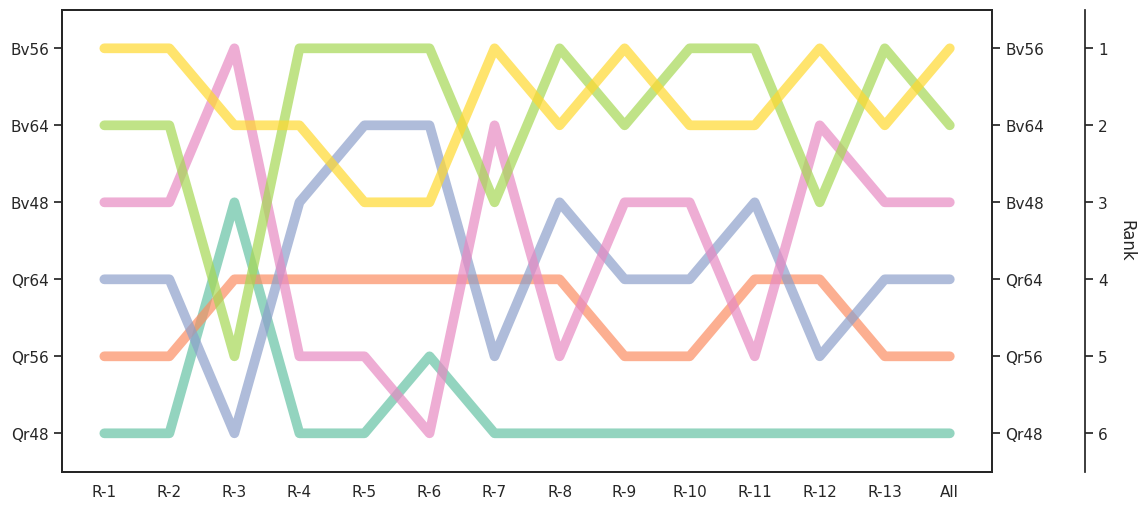

In [ ]:
# after code edit: comment out  -> axis.invert_yaxis() and axis.set_ylim((lines + 0.5, 0.5))
# if show_rank_axis: far_right_yaxis.invert_yaxis() # because 10 is our "best"

reload(bp)

data = rankframe_raters.T  # bumpplot.py expects ranks starting at 1 (best)
sns.set_theme(style="white")
sns.despine(left=True, bottom=True)

#colors = ['#015f5e', '#458b74', '#9f3435', '#018786', '#137887', '#870103', ] #'#159372']
colors = ["#000000", "#a9a9a9", "#a9a9a9", "#000000", "#000000", "#a9a9a9",]
#sns.set_palette(sns.color_palette(colors))
with sns.color_palette(sns.color_palette("Set2"), as_cmap=True):# n_colors=6):
  plt.figure(figsize=(12, 6))
  [lax, rax, frax] = bp.bumpchart(data, show_rank_axis=True, #scatter=True,
                                  line_args= {"linewidth": 7, "alpha": 0.7},
                                  #scatter_args= {'cmap': 'grey'},
                                  rank_axis_distance= 1.1,
                                  scatter_args= {"s": 20, "alpha": 0.8}
                                  )

  frax.set_ylabel("Rank", rotation= -90, labelpad= 20, fontsize= 12,)# weight= "semibold")\

  safig(f'bumpy_{stack}')

  plt.show()

In [ ]:
df_image_rankvalue.name

0      SR_120kV_CTDI10_Bv48_Q3
1       SR_120kV_CTDI5_Bv48_Q3
2       SR_120kV_CTDI3_Bv48_Q3
3     UHR_120kV_CTDI10_Bv48_Q3
4      UHR_120kV_CTDI3_Bv48_Q3
5      UHR_120kV_CTDI5_Bv48_Q3
6      SR_120kV_CTDI10_Bv60_Q3
7      UHR_120kV_CTDI3_Bv60_Q3
8       SR_120kV_CTDI5_Bv60_Q3
9       SR_120kV_CTDI3_Bv60_Q3
10     UHR_120kV_CTDI5_Bv60_Q3
11    UHR_120kV_CTDI10_Bv60_Q3
12      SR_120kV_CTDI3_Bv76_Q3
13      SR_120kV_CTDI5_Bv76_Q3
14     UHR_120kV_CTDI3_Bv76_Q3
15     SR_120kV_CTDI10_Bv76_Q3
16    UHR_120kV_CTDI10_Bv76_Q3
17     UHR_120kV_CTDI5_Bv76_Q3
Name: name, dtype: object

# Creté Roffet

In [ ]:
import skimage as ski
from skimage.io import imread_collection

In [ ]:
cr = pd.DataFrame()

images = imread_collection(os.path.join(maindir, "images/*.png"))
for index, image in enumerate(images):
  filename = images.files[index]
  cr.loc[filename, "crete_roffet"] = ski.measure.blur_effect(image, channel_axis=2)

In [ ]:
cr.to_excel(os.path.join(maindir, "output/crete_roffet.xlsx"))

In [ ]:
cr

,Protege
drive/MyDrive/Medicine/UKW/Forschig/2024 11 Pauline/images/1_1_Bv48.png,0.699718
drive/MyDrive/Medicine/UKW/Forschig/2024 11 Pauline/images/1_1_Bv56.png,0.577180
drive/MyDrive/Medicine/UKW/Forschig/2024 11 Pauline/images/1_1_Bv64.png,0.501191
drive/MyDrive/Medicine/UKW/Forschig/2024 11 Pauline/images/1_1_Qr48.png,0.707012
drive/MyDrive/Medicine/UKW/Forschig/2024 11 Pauline/images/1_1_Qr56.png,0.612619
...,...
drive/MyDrive/Medicine/UKW/Forschig/2024 11 Pauline/images/2_76_Bv56.png,0.460969
drive/MyDrive/Medicine/UKW/Forschig/2024 11 Pauline/images/2_76_Bv64.png,0.383738
drive/MyDrive/Medicine/UKW/Forschig/2024 11 Pauline/images/2_76_Qr48.png,0.576270
drive/MyDrive/Medicine/UKW/Forschig/2024 11 Pauline/images/2_76_Qr56.png,0.470065


# Kendall W

https://www.real-statistics.com/reliability/interrater-reliability/kendalls-w/


* Assume there are **m** raters rating **k** subjects in rank order from 1 to **k**. Let rij = the rating rater j gives to subject i.

* Null hypothesis that W = 0 (i.e. there is no agreement among the raters).

* W is not a correlation coefficient and so we can’t use our usual judgments about correlation coefficients. It turns out, however, that there is a linear transformation of W that is a correlation coefficient, namely:

> **r = (mW - 1) / (m - 1)**

* In fact, it can be shown that r is the average (Spearman) correlation coefficient computed on the ranks of all pairs of raters.


"As for the Friedman test one possible effect size recommended by Tomczak and Tomczak (2014) is Kendall's W (as described by Kendall and Smith (1939)). This is actually a measure of agreement among the respondents, where 0 would represent no agreement at all, and 1 being complete agreement.

For values between 0 and 1 the interpretation will depend on the field you work in. One such interpretation is for example from Cafisio, Di Graziano and Pappalardo (2013, p. 257):

The calculation of Kendall's W is relatively straight forward after you have performed the Friedman test.

> **W = Q / (n * (k - 1))**

-------------------------------------------
https://www.spss-tutorials.com/spss-kendalls-concordance-coefficient-w/

In [ ]:
# IMPORT
from scipy.stats import norm, chi2, kendalltau, friedmanchisquare
import kendall_w.kendall_w as kw

# FUNCTIONS

def calculate_PearsonFromW(kendall_w, m_raters):
  pearson_r = ((m_raters * kendall_w - 1) / (m_raters - 1))
  return pearson_r

def calculate_ChiAndP(kendall_w, m_raters, k_subjects):
  degrees_of_freedom = k_subjects -1
  chi = kendall_w * m_raters * degrees_of_freedom   # https://www.real-statistics.com/reliability/interrater-reliability/kendalls-w/
  p = chi2.sf(chi, degrees_of_freedom)     # https://stackoverflow.com/questions/68832829/chidist-excel-function-in-python
  return chi, p

def calculate_rankcor(data_frame):
  '''input format:
        index:    raters or experiments
        columns:  variables / items to be rated
  '''
  data = np.array(data_frame.values.tolist())
  # using kendall_w.kendall_w as kw
  w = kw.compute_w(data.tolist())

  # manually compute from scipy.stats.friedmanchisquare
  df = data_frame.T
  n, k = df.shape  # k = variables, n = number of "cases" or "raters"
  Q, fp = friedmanchisquare(*[df[c] for c in df.columns])  # *star is for unpacking
  W = Q / (n * (k - 1))

  # kendall w to chi and p value
  wchi, wp = calculate_ChiAndP(w, n, k)
  # kendall w to pearson R
  pearsonR = calculate_PearsonFromW(w, n)

  result_dictionary = {'kendall_w': w, 'friedmanQ': Q, 'friedman p': fp, 'KendallW': W,
                       'kendallToR': pearsonR, 'kendallToChi': wchi, 'kendallToP': wp }
  return result_dictionary



In [ ]:
# RANKS
calculate_rankcor(rankframe_raters)

{'kendall_w': 0.6705539358600583,
 'friedmanQ': 46.93877551020404,
 'friedman p': 5.847110540167124e-09,
 'KendallW': 0.6705539358600577,
 'kendallToR': 0.6452119309262166,
 'kendallToChi': 46.93877551020408,
 'kendallToP': 5.847110540167003e-09}

# IQA – image quality analysis
**example from older project**

In [ ]:
df_iqa = pd.read_excel(os.path.join(maindir, "output/iqa_FR_results.xlsx"))
df_iqa.corr()

<ipython-input-9-7310fd080a06>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_iqa.corr()


,cnr_AbsolutePro,cnr_Protege,ckdn,psnr,ssim,ahiq,lpips,ratings,mit_andi
cnr_AbsolutePro,1.000000,0.881408,-0.809856,0.573709,0.773923,0.886509,0.600196,0.098736,0.099369
cnr_Protege,0.881408,1.000000,-0.741081,0.548144,0.742488,0.831284,0.544192,0.058767,0.063057
ckdn,-0.809856,-0.741081,1.000000,-0.421072,-0.781498,-0.700387,-0.600338,-0.160126,-0.156165
psnr,0.573709,0.548144,-0.421072,1.000000,0.769063,0.684223,-0.080578,0.281133,0.275269
ssim,0.773923,0.742488,-0.781498,0.769063,1.000000,0.867586,0.162293,0.278918,0.271243
ahiq,0.886509,0.831284,-0.700387,0.684223,0.867586,1.000000,0.413597,0.118141,0.116659
lpips,0.600196,0.544192,-0.600338,-0.080578,0.162293,0.413597,1.000000,-0.092020,-0.085374
ratings,0.098736,0.058767,-0.160126,0.281133,0.278918,0.118141,-0.092020,1.000000,0.999291
mit_andi,0.099369,0.063057,-0.156165,0.275269,0.271243,0.116659,-0.085374,0.999291,1.000000


In [ ]:
df_iqa = pd.read_excel(os.path.join(maindir, "output/iqa_NR_results_Links Protege.xlsx"))
df_iqa.corr().round(2)

<ipython-input-15-c694dbf8c663>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_iqa.corr().round(2)


,cnr_Protege,tres,maniqa,maniqa-koniq,musiq,paq2piq,dbcnn,clipiqa,cnniqa,nima,nrqm,ratings,mit_andi
cnr_Protege,1.00,0.73,-0.23,0.50,0.65,0.60,0.56,0.78,0.75,-0.30,-0.64,0.06,0.06
tres,0.73,1.00,-0.48,0.39,0.82,0.50,0.38,0.74,0.74,-0.42,-0.90,0.23,0.23
maniqa,-0.23,-0.48,1.00,0.24,-0.72,0.22,0.21,0.00,-0.07,-0.45,0.28,-0.17,-0.16
maniqa-koniq,0.50,0.39,0.24,1.00,-0.01,0.93,0.95,0.83,0.85,-0.67,-0.57,-0.08,-0.08
musiq,0.65,0.82,-0.72,-0.01,1.00,0.12,0.05,0.42,0.44,0.07,-0.62,0.13,0.13
paq2piq,0.60,0.50,0.22,0.93,0.12,1.00,0.97,0.93,0.92,-0.73,-0.68,-0.03,-0.02
dbcnn,0.56,0.38,0.21,0.95,0.05,0.97,1.00,0.86,0.86,-0.60,-0.56,-0.06,-0.06
clipiqa,0.78,0.74,0.00,0.83,0.42,0.93,0.86,1.00,0.97,-0.72,-0.83,0.06,0.06
cnniqa,0.75,0.74,-0.07,0.85,0.44,0.92,0.86,0.97,1.00,-0.64,-0.85,0.04,0.04
nima,-0.30,-0.42,-0.45,-0.67,0.07,-0.73,-0.60,-0.72,-0.64,1.00,0.63,-0.06,-0.05
